<a href="https://colab.research.google.com/github/rianeps/martian-rover-adaptive-replanning/blob/main/martian_rover_baseline.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Martian Rover — Baseline Navigation System

---

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


##  Install & Import Dependencies

In [1]:

import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import heapq

print('All dependencies loaded successfully!')

All dependencies loaded successfully!


---
## Terrain Map

The terrain grid simulates a section of Martian surface.
Each cell is one of three types:

| Type | Value | Traversal Cost | Description |
|------|-------|---------------|-------------|
| Safe | 0 | 1 | Flat, traversable ground |
| Rocky | 1 | 5 | Rough terrain, slow and risky |
| Hazardous | 2 | ∞ | Craters, deep rocks — impassable |

The cost values feed directly into A* — the planner will prefer safe routes even if they are longer.

In [ ]:
# ── Terrain Constants ──────────────────────────────────────────────────────
SAFE      = 0
ROCKY     = 1
HAZARDOUS = 2

TERRAIN_COST = {
    SAFE:      1,
    ROCKY:     5,
    HAZARDOUS: float('inf')
}

TERRAIN_LABELS = {
    SAFE:      'Safe',
    ROCKY:     'Rocky',
    HAZARDOUS: 'Hazardous'
}


# ── Terrain Generator ─────────────────────────────────────────────────────
def generate_terrain(grid_size=30, seed=42):
    """
    Generate a random Martian terrain grid.
    Uses circular blobs to simulate craters (hazardous)
    and rocky patches scattered across the surface.

    Args:
        grid_size: size of the square grid (NxN)
        seed:      random seed for reproducibility

    Returns:
        grid: 2D numpy array of terrain types
    """
    rng  = np.random.default_rng(seed)
    grid = np.zeros((grid_size, grid_size), dtype=int)

    # Place hazardous zones (craters)
    num_hazards = grid_size // 4
    for _ in range(num_hazards):
        cx     = rng.integers(2, grid_size - 2)
        cy     = rng.integers(2, grid_size - 2)
        radius = rng.integers(1, 4)
        for x in range(grid_size):
            for y in range(grid_size):
                if (x - cx)**2 + (y - cy)**2 <= radius**2:
                    grid[x][y] = HAZARDOUS

    # Place rocky zones (rough terrain patches)
    num_rocky = grid_size // 2
    for _ in range(num_rocky):
        cx     = rng.integers(0, grid_size)
        cy     = rng.integers(0, grid_size)
        radius = rng.integers(1, 3)
        for x in range(grid_size):
            for y in range(grid_size):
                if (x - cx)**2 + (y - cy)**2 <= radius**2:
                    if grid[x][y] == SAFE:  # Don't overwrite hazards
                        grid[x][y] = ROCKY

    return grid


def get_cost(grid, x, y):
    """Return traversal cost of a cell."""
    return TERRAIN_COST[grid[x][y]]


def is_passable(grid, x, y):
    """Return True if a cell can be traversed."""
    return grid[x][y] != HAZARDOUS


# ── Generate and inspect terrain ──────────────────────────────────────────
GRID_SIZE = 30
grid      = generate_terrain(grid_size=GRID_SIZE, seed=42)

total     = GRID_SIZE * GRID_SIZE
safe_pct  = (grid == SAFE).sum()      / total * 100
rocky_pct = (grid == ROCKY).sum()     / total * 100
haz_pct   = (grid == HAZARDOUS).sum() / total * 100

print(f'Grid size:  {GRID_SIZE} x {GRID_SIZE}')
print(f'Safe:       {safe_pct:.1f}%')
print(f'Rocky:      {rocky_pct:.1f}%')
print(f'Hazardous:  {haz_pct:.1f}%')

Grid size:  30 x 30
Safe:       77.2%
Rocky:      9.6%
Hazardous:  13.2%


---
##  A\* Path Planner

A\* finds the **lowest-cost path** from start to goal on the terrain grid.

**Why A\* over alternatives:**
- Works natively on grid maps (exactly what our terrain classifier produces)
- Terrain costs are incorporated directly into path selection
- Fast to rerun — critical for the adaptive replanning component
- Guaranteed to find the optimal path if one exists

**Heuristic:** Manhattan distance (admissible for 4-directional movement)

In [ ]:
# ── A* Algorithm ──────────────────────────────────────────────────────────
def heuristic(a, b):
    """Manhattan distance — admissible heuristic for 4-directional grid movement."""
    return abs(a[0] - b[0]) + abs(a[1] - b[1])


def get_neighbours(grid, x, y):
    """
    Return passable neighbouring cells.
    4-directional movement: up, down, left, right.
    """
    directions = [(-1, 0), (1, 0), (0, -1), (0, 1)]
    neighbours = []
    rows, cols = grid.shape

    for dx, dy in directions:
        nx, ny = x + dx, y + dy
        if 0 <= nx < rows and 0 <= ny < cols:
            if is_passable(grid, nx, ny):
                neighbours.append((nx, ny))

    return neighbours


def astar(grid, start, goal):
    """
    A* pathfinding on a terrain cost grid.

    Args:
        grid:  2D numpy array of terrain types
        start: (row, col) tuple
        goal:  (row, col) tuple

    Returns:
        path:       list of (row, col) tuples, or None if unreachable
        total_cost: cumulative traversal cost
    """
    open_set = []
    heapq.heappush(open_set, (0, 0, start))

    g_score  = {start: 0}
    came_from = {}
    visited   = set()

    while open_set:
        f, g, current = heapq.heappop(open_set)

        if current in visited:
            continue
        visited.add(current)

        if current == goal:
            # Reconstruct path
            path = []
            node = goal
            while node in came_from:
                path.append(node)
                node = came_from[node]
            path.append(start)
            path.reverse()
            return path, g_score[goal]

        for neighbour in get_neighbours(grid, *current):
            if neighbour in visited:
                continue

            step_cost    = get_cost(grid, *neighbour)
            tentative_g  = g_score[current] + step_cost

            if tentative_g < g_score.get(neighbour, float('inf')):
                came_from[neighbour] = current
                g_score[neighbour]   = tentative_g
                f_score              = tentative_g + heuristic(neighbour, goal)
                heapq.heappush(open_set, (f_score, tentative_g, neighbour))

    return None, float('inf')


# ── Run A* ────────────────────────────────────────────────────────────────
START = (2, 2)
GOAL  = (27, 27)

path, cost = astar(grid, START, GOAL)

if path:
    print(f'Path found!')
    print(f'Steps:       {len(path)}')
    print(f'Total cost:  {cost:.1f}  (safe=1, rocky=5 per cell)')
else:
    print('No path found — goal is unreachable.')

Path found!
Steps:       51
Total cost:  50.0  (safe=1, rocky=5 per cell)


---
##  Visualisation

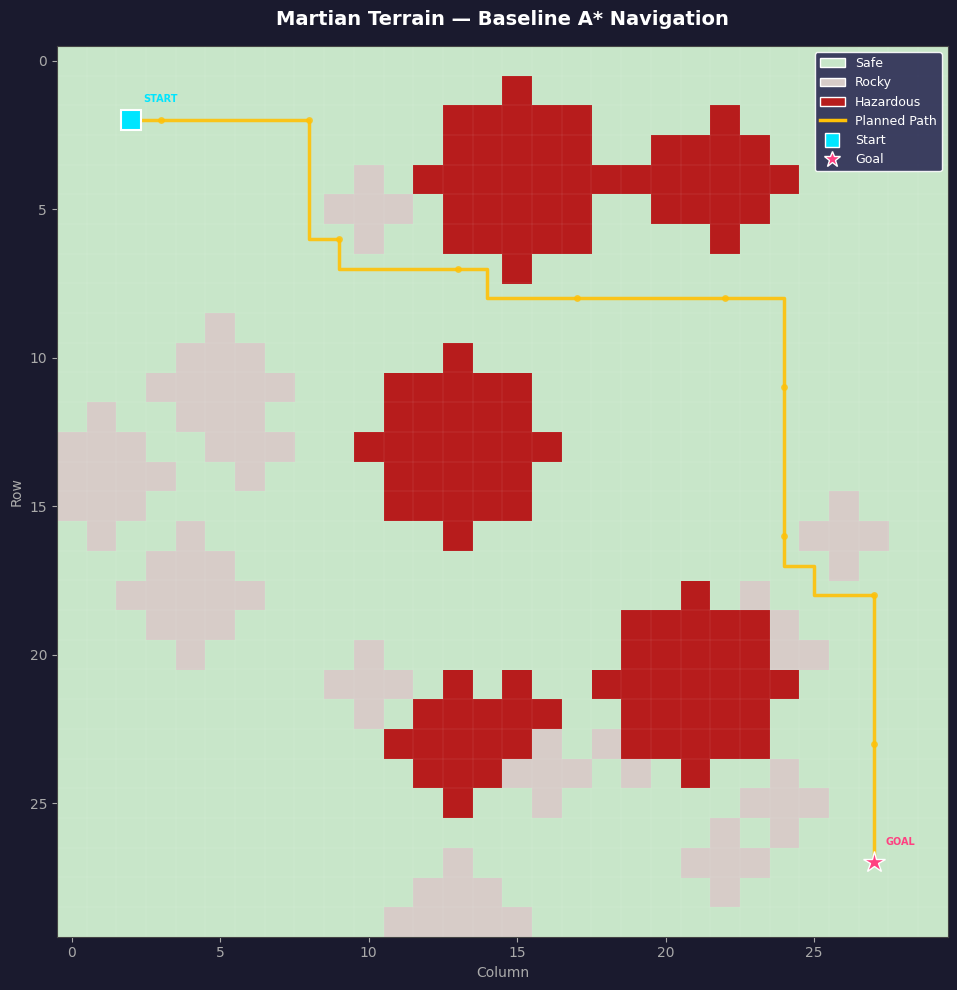

In [ ]:
# ── Colour Map ────────────────────────────────────────────────────────────
COLOUR_ARRAY = np.array([
    [200, 230, 201],   # SAFE      — soft green
    [215, 204, 200],   # ROCKY     — warm grey
    [183,  28,  28],   # HAZARDOUS — deep red
], dtype=np.uint8)


def terrain_to_rgb(grid):
    """Convert terrain type grid to RGB image array."""
    rgb = np.zeros((*grid.shape, 3), dtype=np.uint8)
    for terrain_type, colour in zip([SAFE, ROCKY, HAZARDOUS], COLOUR_ARRAY):
        rgb[grid == terrain_type] = colour
    return rgb


def visualise(grid, path=None, start=None, goal=None,
              title='Martian Terrain Navigation', save_path=None):
    """
    Visualise the terrain grid and planned path.

    Args:
        grid:      2D numpy terrain array
        path:      list of (row, col) tuples
        start:     (row, col) start position
        goal:      (row, col) goal position
        title:     plot title string
        save_path: optional path to save the figure as PNG
    """
    fig, ax = plt.subplots(figsize=(10, 10))
    fig.patch.set_facecolor('#1A1A2E')
    ax.set_facecolor('#1A1A2E')

    # Terrain
    ax.imshow(terrain_to_rgb(grid), origin='upper', interpolation='nearest')

    # Grid lines
    rows, cols = grid.shape
    for x in range(cols + 1):
        ax.axvline(x - 0.5, color='white', linewidth=0.2, alpha=0.3)
    for y in range(rows + 1):
        ax.axhline(y - 0.5, color='white', linewidth=0.2, alpha=0.3)

    # Path
    if path and len(path) > 1:
        ax.plot([p[1] for p in path], [p[0] for p in path],
                color='#FFC107', linewidth=2.5, zorder=3, alpha=0.9)
        step = max(1, len(path) // 10)
        for i in range(1, len(path) - 1, step):
            ax.plot(path[i][1], path[i][0], 'o',
                    color='#FFC107', markersize=4, zorder=4, alpha=0.7)

    # Start & Goal markers
    if start:
        ax.plot(start[1], start[0], 's', color='#00E5FF', markersize=14,
                zorder=5, markeredgecolor='white', markeredgewidth=1.5)
        ax.text(start[1] + 0.4, start[0] - 0.6, 'START',
                color='#00E5FF', fontsize=7, fontweight='bold', zorder=6)

    if goal:
        ax.plot(goal[1], goal[0], '*', color='#FF4081', markersize=16,
                zorder=5, markeredgecolor='white', markeredgewidth=1.0)
        ax.text(goal[1] + 0.4, goal[0] - 0.6, 'GOAL',
                color='#FF4081', fontsize=7, fontweight='bold', zorder=6)

    # Legend
    legend_elements = [
        mpatches.Patch(facecolor='#C8E6C9', edgecolor='white', label='Safe'),
        mpatches.Patch(facecolor='#D7CCC8', edgecolor='white', label='Rocky'),
        mpatches.Patch(facecolor='#B71C1C', edgecolor='white', label='Hazardous'),
        plt.Line2D([0], [0], color='#FFC107', linewidth=2.5, label='Planned Path'),
        plt.Line2D([0], [0], marker='s', color='w', markerfacecolor='#00E5FF',
                   markersize=10, label='Start', linestyle='None'),
        plt.Line2D([0], [0], marker='*', color='w', markerfacecolor='#FF4081',
                   markersize=12, label='Goal',  linestyle='None'),
    ]
    ax.legend(handles=legend_elements, loc='upper right',
              facecolor='#2C2C54', edgecolor='white',
              labelcolor='white', fontsize=9, framealpha=0.9)

    ax.set_title(title, color='white', fontsize=14, fontweight='bold', pad=15)
    ax.set_xlabel('Column', color='#AAAAAA', fontsize=10)
    ax.set_ylabel('Row',    color='#AAAAAA', fontsize=10)
    ax.tick_params(colors='#AAAAAA')
    for spine in ax.spines.values():
        spine.set_edgecolor('#444444')

    plt.tight_layout()

    if save_path:
        plt.savefig(save_path, dpi=150, bbox_inches='tight',
                    facecolor=fig.get_facecolor())
        print(f'Saved to {save_path}')

    plt.show()
    plt.close()


# ── Render ────────────────────────────────────────────────────────────────
visualise(
    grid, path=path, start=START, goal=GOAL,
    title='Martian Terrain — Baseline A* Navigation'
)

No path found.


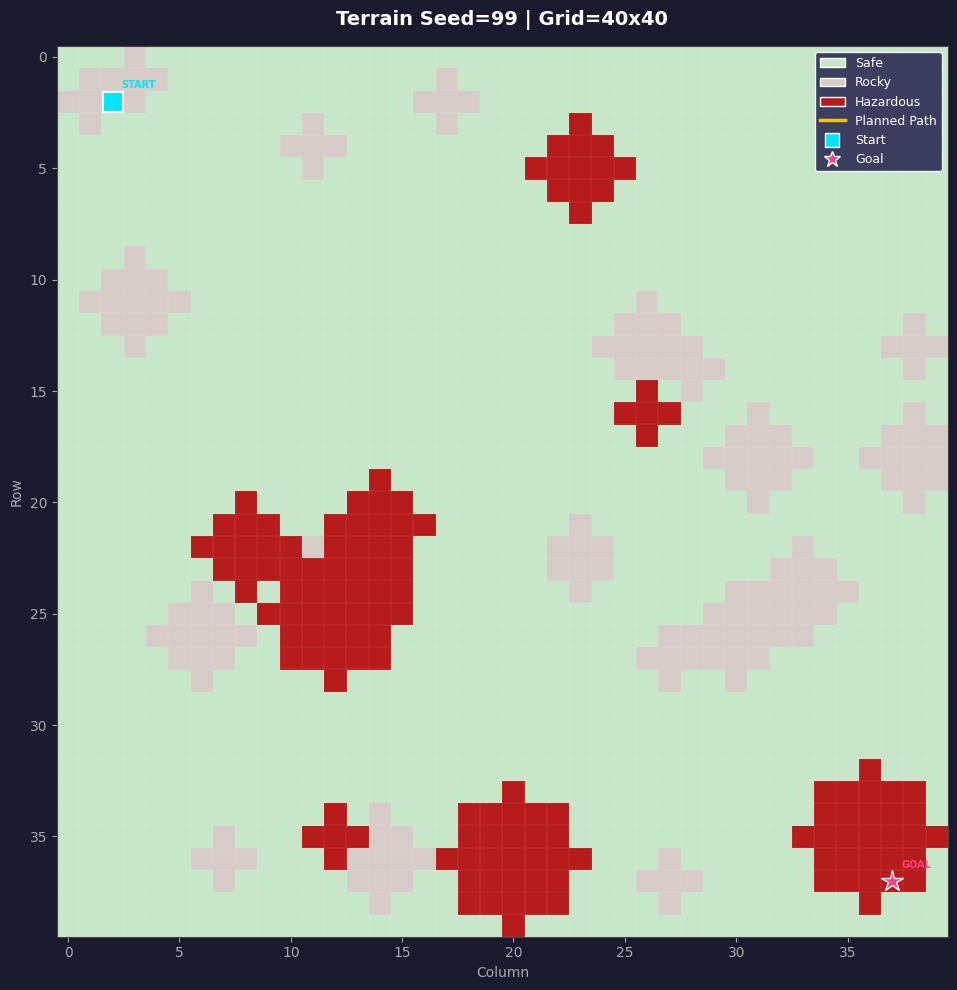

In [ ]:

EXPERIMENT_GRID_SIZE = 40       # try 20, 30, 40, 50
EXPERIMENT_SEED      = 99       # any integer — different seeds = different terrain
EXPERIMENT_START     = (2, 2)
EXPERIMENT_GOAL      = (37, 37)

exp_grid           = generate_terrain(grid_size=EXPERIMENT_GRID_SIZE, seed=EXPERIMENT_SEED)
exp_path, exp_cost = astar(exp_grid, EXPERIMENT_START, EXPERIMENT_GOAL)

if exp_path:
    print(f'Path found — Steps: {len(exp_path)} | Cost: {exp_cost:.1f}')
else:
    print('No path found.')

visualise(
    exp_grid, path=exp_path,
    start=EXPERIMENT_START, goal=EXPERIMENT_GOAL,
    title=f'Terrain Seed={EXPERIMENT_SEED} | Grid={EXPERIMENT_GRID_SIZE}x{EXPERIMENT_GRID_SIZE}'
)


## Baseline Evaluation


In [ ]:
# ── Evaluate across multiple seeds ────────────────────────────────────────
EVAL_GRID_SIZE = 30
EVAL_START     = (2, 2)
EVAL_GOAL      = (27, 27)
NUM_SEEDS      = 20

results = []

for seed in range(NUM_SEEDS):
    g            = generate_terrain(grid_size=EVAL_GRID_SIZE, seed=seed)
    p, c         = astar(g, EVAL_START, EVAL_GOAL)
    success      = p is not None
    steps        = len(p) if success else 0
    safe_steps   = sum(1 for cell in p if g[cell[0]][cell[1]] == SAFE)   if success else 0
    rocky_steps  = sum(1 for cell in p if g[cell[0]][cell[1]] == ROCKY)  if success else 0

    results.append({
        'seed':        seed,
        'success':     success,
        'steps':       steps,
        'cost':        round(c, 1) if success else None,
        'safe_steps':  safe_steps,
        'rocky_steps': rocky_steps,
    })

# Print results table
print(f'{"Seed":>5} | {"Success":>7} | {"Steps":>6} | {"Cost":>7} | {"Safe":>5} | {"Rocky":>6}')
print('-' * 52)
for r in results:
    print(f'{r["seed"]:>5} | {str(r["success"]):>7} | {r["steps"]:>6} | '
          f'{str(r["cost"]):>7} | {r["safe_steps"]:>5} | {r["rocky_steps"]:>6}')

# Summary
success_rate = sum(r['success'] for r in results) / NUM_SEEDS * 100
avg_steps    = np.mean([r['steps'] for r in results if r['success']])
avg_cost     = np.mean([r['cost']  for r in results if r['success']])

print(f'\nSummary across {NUM_SEEDS} terrain seeds:')
print(f'  Success rate:  {success_rate:.1f}%')
print(f'  Avg steps:     {avg_steps:.1f}')
print(f'  Avg cost:      {avg_cost:.1f}')

 Seed | Success |  Steps |    Cost |  Safe |  Rocky
----------------------------------------------------
    0 |    True |     51 |      50 |    50 |      0
    1 |   False |      0 |    None |     0 |      0
    2 |    True |     55 |      58 |    54 |      1
    3 |    True |     51 |      50 |    50 |      0
    4 |    True |     51 |      50 |    51 |      0
    5 |    True |     51 |      50 |    50 |      0
    6 |    True |     51 |      50 |    51 |      0
    7 |    True |     53 |      52 |    53 |      0
    8 |    True |     51 |      50 |    51 |      0
    9 |    True |     55 |      70 |    51 |      4
   10 |    True |     51 |      50 |    51 |      0
   11 |    True |     53 |      56 |    52 |      1
   12 |    True |     51 |      54 |    50 |      1
   13 |    True |     53 |      52 |    53 |      0
   14 |    True |     51 |      54 |    50 |      1
   15 |    True |     51 |      50 |    51 |      0
   16 |    True |     51 |      50 |    51 |      0
   17 |   F